In [1]:
from google.colab import files
uploaded = files.upload()

Saving pathological_data_filtered.csv to pathological_data_filtered.csv
Saving clinical_data_filtered.csv to clinical_data_filtered.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df_c = pd.read_csv("clinical_data_filtered.csv")
df_p = pd.read_csv("pathological_data_filtered.csv")
df   = pd.merge(df_c, df_p, on="patient_id")

# Drop CUP (only 1 sample)
df = df[df["primary_tumor_site"] != "CUP"].reset_index(drop=True)

# Separate grading and HPV — they share the grading column
# HPV-positive patients have 'hpv_association_p16' as grading value
df["grading_clean"] = df["grading"].apply(lambda x: x if x in ["G1","G2","G3"] else None)
df["hpv_status"]    = df["hpv_association_p16"]  # already its own column

print(f"Dataset: {df.shape[0]} patients x {df.shape[1]} columns")
df[["patient_id","primary_tumor_site","grading_clean","hpv_status"]].head(10)


Dataset: 180 patients x 51 columns


,patient_id,primary_tumor_site,grading_clean,hpv_status
0,102,Larynx,G3,not_tested
1,104,Oropharynx,G2,negative
2,111,Oral_Cavity,G2,not_tested
3,113,Oropharynx,G3,negative
4,114,Oropharynx,None,positive
5,117,Larynx,G2,not_tested
6,121,Oropharynx,G3,negative
7,122,Larynx,G2,not_tested
8,123,Larynx,G3,not_tested
9,125,Hypopharynx,G2,not_tested


## Target Variable Distributions

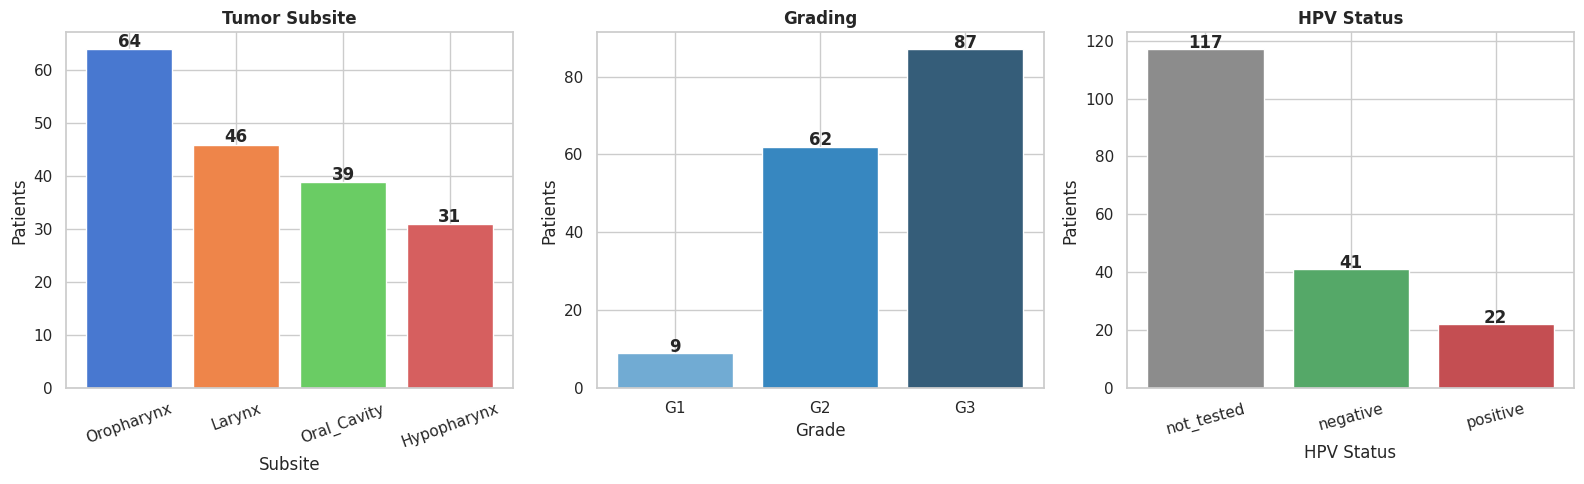

Subsite: {'Oropharynx': 35.6, 'Larynx': 25.6, 'Oral_Cavity': 21.7, 'Hypopharynx': 17.2}
Grading: {'G1': 5.7, 'G2': 39.2, 'G3': 55.1}
HPV:     {'not_tested': 65.0, 'negative': 22.8, 'positive': 12.2}


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Target 1: Tumor subsite
site_counts = df["primary_tumor_site"].value_counts()
axes[0].bar(site_counts.index, site_counts.values,
            color=sns.color_palette("muted", len(site_counts)), edgecolor="white")
axes[0].set_title("Tumor Subsite", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Subsite"); axes[0].set_ylabel("Patients")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(site_counts.values):
    axes[0].text(i, v + 0.4, str(v), ha="center", fontweight="bold")

# Target 2: Grading
grade_counts = df["grading_clean"].value_counts().reindex(["G1","G2","G3"])
axes[1].bar(grade_counts.index, grade_counts.values,
            color=sns.color_palette("Blues_d", 3), edgecolor="white")
axes[1].set_title("Grading", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Grade"); axes[1].set_ylabel("Patients")
for i, v in enumerate(grade_counts.values):
    axes[1].text(i, v + 0.4, str(int(v)), ha="center", fontweight="bold")

# Target 3: HPV status
hpv_counts = df["hpv_status"].value_counts()
colors_hpv = {"positive": "#C44E52", "negative": "#55A868", "not_tested": "#8C8C8C"}
bar_colors = [colors_hpv.get(x, "#4C72B0") for x in hpv_counts.index]
axes[2].bar(hpv_counts.index, hpv_counts.values, color=bar_colors, edgecolor="white")
axes[2].set_title("HPV Status", fontsize=12, fontweight="bold")
axes[2].set_xlabel("HPV Status"); axes[2].set_ylabel("Patients")
axes[2].tick_params(axis="x", rotation=15)
for i, v in enumerate(hpv_counts.values):
    axes[2].text(i, v + 0.4, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("target_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Subsite:", (site_counts/len(df)*100).round(1).to_dict())
print("Grading:", (grade_counts/df["grading_clean"].notna().sum()*100).round(1).to_dict())
print("HPV:    ", (hpv_counts/len(df)*100).round(1).to_dict())

## Patient Demographics

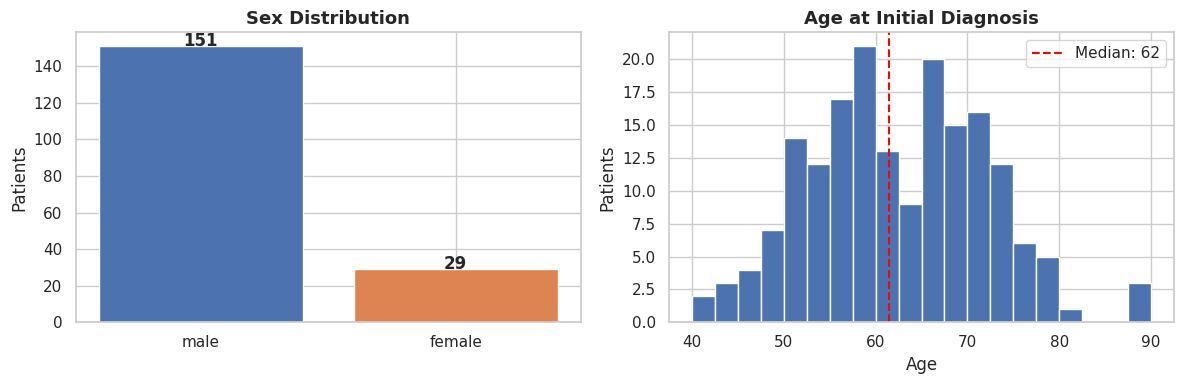

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sex_counts = df["sex"].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values,
            color=["#4C72B0","#DD8452"], edgecolor="white")
axes[0].set_title("Sex Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Patients")
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

axes[1].hist(df["age_at_initial_diagnosis"], bins=20, color="#4C72B0", edgecolor="white")
axes[1].set_title("Age at Initial Diagnosis", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Age"); axes[1].set_ylabel("Patients")
med = df["age_at_initial_diagnosis"].median()
axes[1].axvline(med, color="red", linestyle="--", label=f"Median: {med:.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("demographics.png", dpi=150, bbox_inches="tight")
plt.show()

## Relationships Between Targets

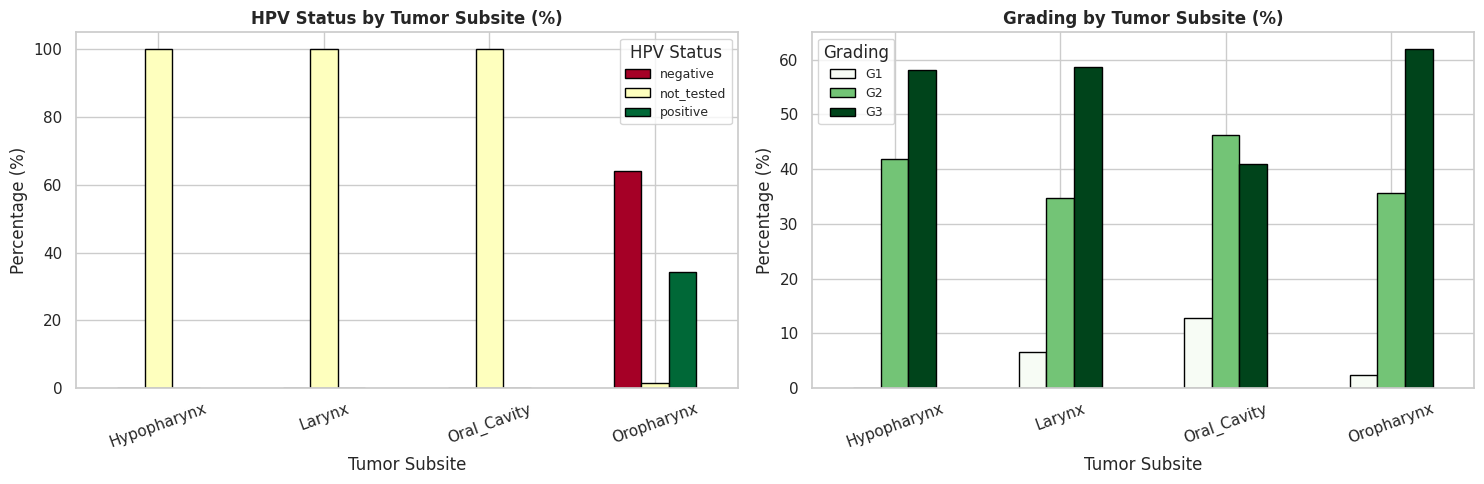

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# HPV by subsite
ct1 = pd.crosstab(df["primary_tumor_site"], df["hpv_status"], normalize="index") * 100
ct1.plot(kind="bar", ax=axes[0], colormap="RdYlGn", edgecolor="black")
axes[0].set_title("HPV Status by Tumor Subsite (%)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Tumor Subsite"); axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="HPV Status", fontsize=9)

# Grading by subsite
ct2 = pd.crosstab(df["primary_tumor_site"], df["grading_clean"], normalize="index") * 100
ct2.plot(kind="bar", ax=axes[1], colormap="Greens", edgecolor="black")
axes[1].set_title("Grading by Tumor Subsite (%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Tumor Subsite"); axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Grading", fontsize=9)

plt.tight_layout()
plt.savefig("targets_vs_targets.png", dpi=150, bbox_inches="tight")
plt.show()

## pT and pN Stage (Input Features)

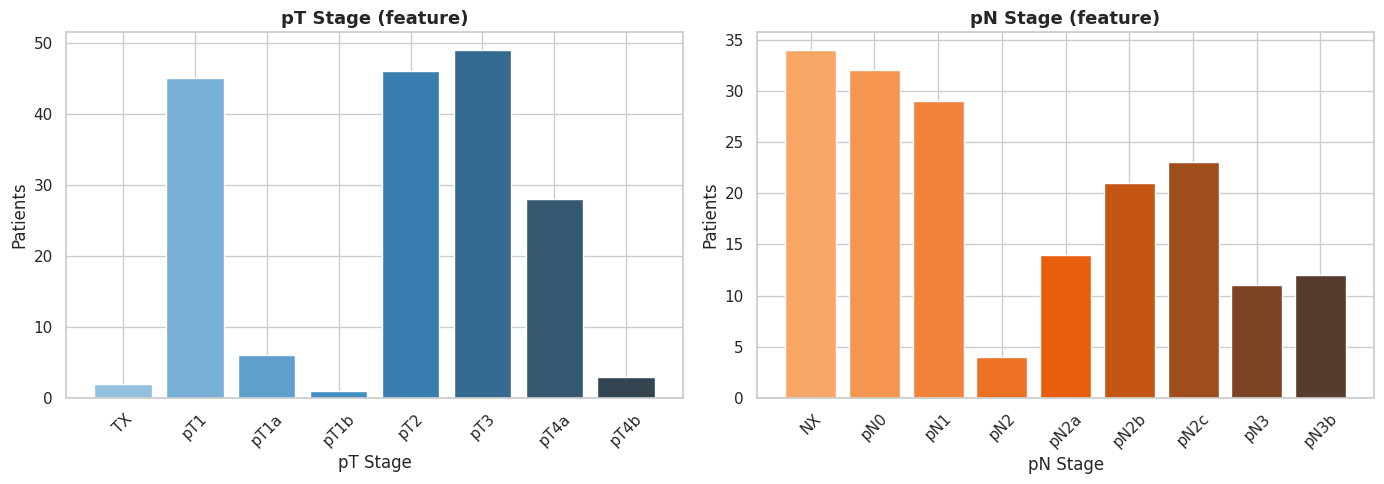

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pt = df["pT_stage"].value_counts().sort_index()
axes[0].bar(pt.index, pt.values,
            color=sns.color_palette("Blues_d", len(pt)), edgecolor="white")
axes[0].set_title("pT Stage (feature)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("pT Stage"); axes[0].set_ylabel("Patients")
axes[0].tick_params(axis="x", rotation=45)

pn = df["pN_stage"].value_counts().sort_index()
axes[1].bar(pn.index, pn.values,
            color=sns.color_palette("Oranges_d", len(pn)), edgecolor="white")
axes[1].set_title("pN Stage (feature)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("pN Stage"); axes[1].set_ylabel("Patients")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("staging.png", dpi=150, bbox_inches="tight")
plt.show()


## Missing Data

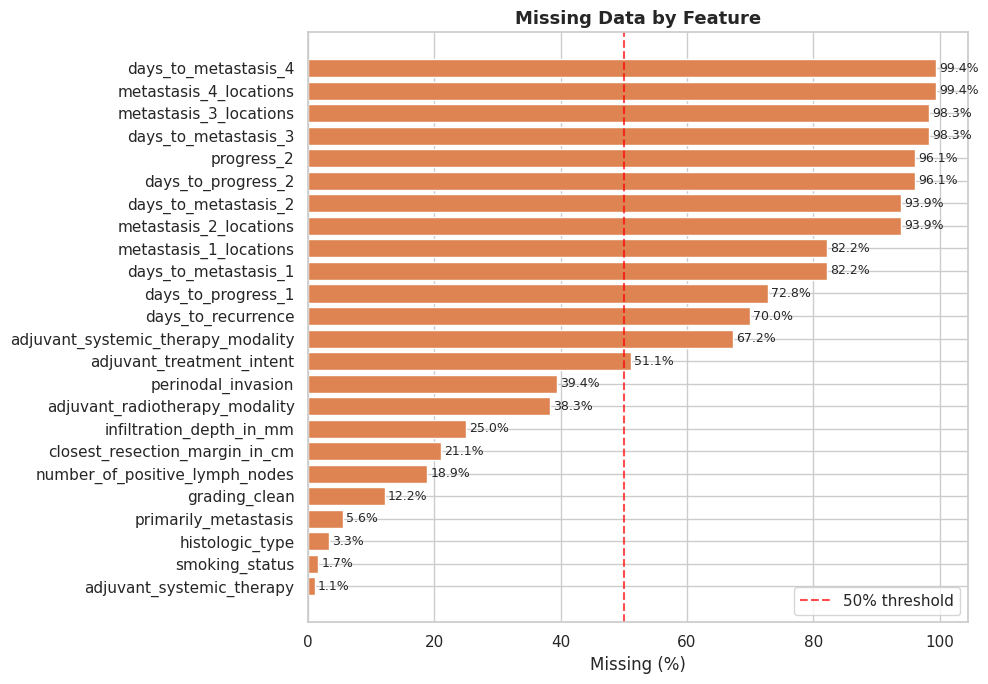

Features >50% missing (consider dropping):
adjuvant_treatment_intent             51.1
adjuvant_systemic_therapy_modality    67.2
days_to_recurrence                    70.0
days_to_progress_1                    72.8
days_to_metastasis_1                  82.2
metastasis_1_locations                82.2
metastasis_2_locations                93.9
days_to_metastasis_2                  93.9
days_to_progress_2                    96.1
progress_2                            96.1
days_to_metastasis_3                  98.3
metastasis_3_locations                98.3
metastasis_4_locations                99.4
days_to_metastasis_4                  99.4


In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(missing.index, missing_pct.values, color="#DD8452", edgecolor="white")
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Data by Feature", fontsize=13, fontweight="bold")
ax.axvline(50, color="red", linestyle="--", alpha=0.7, label="50% threshold")
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("missing_data.png", dpi=150, bbox_inches="tight")
plt.show()

print("Features >50% missing (consider dropping):")
print(missing_pct[missing_pct > 50].to_string())


## Smoking Status

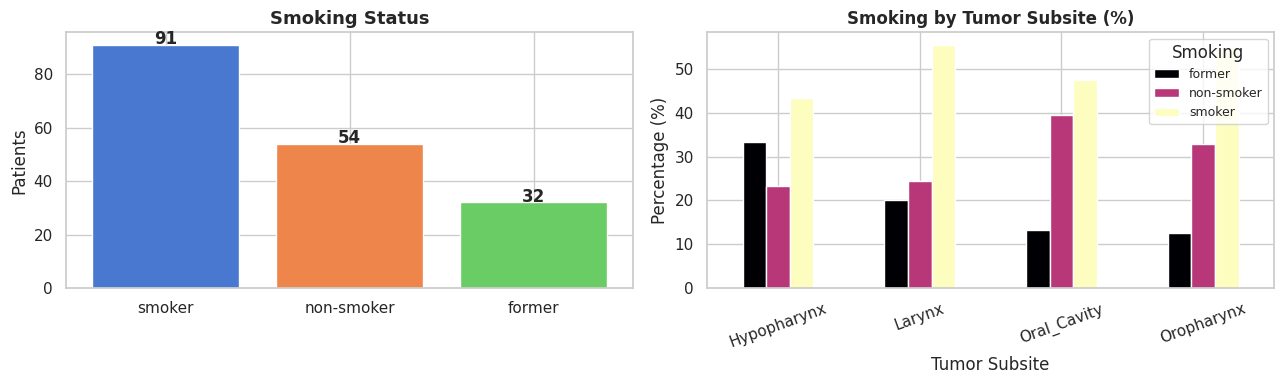

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

smoke = df["smoking_status"].value_counts()
axes[0].bar(smoke.index, smoke.values,
            color=sns.color_palette("muted", len(smoke)), edgecolor="white")
axes[0].set_title("Smoking Status", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Patients")
for i, v in enumerate(smoke.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

ct_smoke = pd.crosstab(df["primary_tumor_site"], df["smoking_status"], normalize="index") * 100
ct_smoke.plot(kind="bar", ax=axes[1], colormap="magma", edgecolor="white")
axes[1].set_title("Smoking by Tumor Subsite (%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Tumor Subsite"); axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Smoking", fontsize=9)

plt.tight_layout()
plt.savefig("smoking.png", dpi=150, bbox_inches="tight")
plt.show()


## Notes

**Target 1: Tumor Subsite:**
- 4 classes after dropping CUP: Oropharynx (64), Larynx (46), Oral Cavity (39), Hypopharynx (31)
- Mild imbalance maybe use weighted cross-entropy loss

**Target 2:  Grading:**
- 3 classes: G3 (88), G2 (62), G1 (9)
- G1 severely underrepresented so maybe use oversampling or weighted loss
- Note: grading is missing for HPV-positive patients (their grading column = 'hpv_association_p16')

**Target 3: HPV Status:**
- 3 classes: not_tested (117), negative (42), positive (22)
- Consider binary classification (positive vs negative) using only the 64 tested patients
- HPV-positive cases cluster strongly in Oropharynx model should capture this

**Features for clinical encoder:**
- `age_at_initial_diagnosis`, `sex`, `smoking_status`
- `pT_stage`, `pN_stage` (ordinal encoding)
- `perinodal_invasion`, `lymphovascular_invasion_L`, `perineural_invasion_Pn`, `resection_status`

**Features to drop (>50% missing):**
- `metastasis_2-4_*`, `days_to_progress_2`, `adjuvant_systemic_therapy_modality`
